# Computer Exercise 9.3 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 9.3 Other Examples of the Least-Squares Principle — *가중최소제곱(WLS)과 가우스–마르코프 정리*
> **풀이 일자**: Day 36
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)


## 1. 문제 (원문)

> **2.** Measurements $y_i$ at points $x_i$ have *non-uniform* reliability: the $i$-th
> observation has known standard deviation $\sigma_i$. Fit a straight line
> $y=c_0+c_1 x$ by both ordinary least squares (treating all points equally) and by
> **weighted least squares** with weights $w_i=1/\sigma_i^2$. Verify experimentally,
> via repeated simulation, that the weighted estimator has the smaller variance,
> as guaranteed by the Gauss–Markov theorem.

### 한국어 풀이용 정리
관측값마다 신뢰도(표준편차 $\sigma_i$)가 다른 **이분산(heteroscedastic)** 상황에서 직선 $y=c_0+c_1x$ 를 맞춘다.
모든 점을 똑같이 보는 **보통최소제곱(OLS)** 과, 분산의 역수 $w_i=1/\sigma_i^2$ 로 가중하는 **가중최소제곱(WLS)** 을 비교한다.
**가우스–마르코프 정리**가 약속하는 "WLS 가 분산 최소(BLUE)"를 몬테카를로로 *직접 확인*한다.


## 2. 수학적 배경

### 2.1 가중정규방정식
설계행렬 $A=[\,\mathbf 1\ \ \mathbf x\,]\in\mathbb R^{m\times2}$, 가중행렬 $W=\operatorname{diag}(w_1,\dots,w_m)$ 일 때
가중 잔차제곱합 $\;(\,\mathbf y-A\mathbf c\,)^\top W(\,\mathbf y-A\mathbf c\,)\;$ 의 최소화는
$$
\boxed{\;A^\top W A\,\hat{\mathbf c}=A^\top W\,\mathbf y\;}
$$
를 푼다. $W=I$ 이면 보통최소제곱(OLS)이다.

### 2.2 추정량의 공분산과 가우스–마르코프
오차가 평균 0, 공분산 $\operatorname{Cov}(\boldsymbol\varepsilon)=\Sigma=\operatorname{diag}(\sigma_i^2)$ 이고
**$W=\Sigma^{-1}$** (즉 $w_i=1/\sigma_i^2$) 로 잡으면, 추정량은 *비편향*이고 그 공분산은
$$
\operatorname{Cov}(\hat{\mathbf c}_{\text{WLS}})=(A^\top\Sigma^{-1}A)^{-1}.
$$
**가우스–마르코프 정리**: 선형 비편향 추정량 중 이 WLS 추정량이 **최소분산**(BLUE).
임의의 다른 가중(특히 OLS, $W=I$)은 같은 비편향이라도 분산이 더 크거나 같다:
$$
\operatorname{Cov}(\hat{\mathbf c}_{\text{OLS}})-\operatorname{Cov}(\hat{\mathbf c}_{\text{WLS}})\succeq 0\ \text{(양반정치)}.
$$

### 2.3 OLS 의 공분산 (참고)
$\hat{\mathbf c}_{\text{OLS}}=(A^\top A)^{-1}A^\top\mathbf y$ 의 공분산은
$(A^\top A)^{-1}A^\top \Sigma A (A^\top A)^{-1}$ 로, $\Sigma\ne\sigma^2 I$ 이면 WLS 보다 항상 부풀어 있다.


## 3. 풀이 흐름

1. 참 직선 $c_0^\star=1.0,\ c_1^\star=2.0$ 과 $x\in[0,10]$ 의 $m=20$ 점을 정한다.
2. 점마다 표준편차 $\sigma_i$ 를 *체계적으로 변하게* 준다(예: $x$ 가 클수록 측정이 부정확).
3. **이론 공분산**을 두 추정량에 대해 식으로 계산해 둔다.
4. 한 번의 실현에서 OLS·WLS 적합선을 그려 비교한다(오차막대 포함).
5. **몬테카를로 4000회**: 매번 새 잡음으로 두 추정량을 구해, 추정량들의 *경험적 표준편차*를 측정.
6. 경험적 표준편차 ↔ 이론 표준편차가 일치하는지, WLS < OLS 인지 표와 히스토그램으로 확인.
7. 가우스–마르코프의 의미를 해석한다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
rng = np.random.default_rng(360609)

# 참 직선
c0_true, c1_true = 1.0, 2.0
m = 20
x = np.linspace(0.0, 10.0, m)
A = np.column_stack([np.ones(m), x])          # 설계행렬

# 이분산: x 가 클수록 측정 표준편차 증가 (0.5 -> 5.0)
sigma = 0.5 + 0.45 * x
W = np.diag(1.0 / sigma**2)                    # 최적 가중 = 1/sigma^2
Sigma = np.diag(sigma**2)

# 이론 공분산
cov_wls = np.linalg.inv(A.T @ W @ A)
AtA_inv = np.linalg.inv(A.T @ A)
cov_ols = AtA_inv @ A.T @ Sigma @ A @ AtA_inv

theo = pd.DataFrame({
    "param": ["c0 (intercept)", "c1 (slope)"],
    "std OLS (theory)": np.sqrt(np.diag(cov_ols)),
    "std WLS (theory)": np.sqrt(np.diag(cov_wls)),
})
theo["OLS/WLS ratio"] = theo["std OLS (theory)"] / theo["std WLS (theory)"]
theo


,param,std OLS (theory),std WLS (theory),OLS/WLS ratio
0,c0 (intercept),0.8452,0.3813,2.2168
1,c1 (slope),0.2433,0.1588,1.5324


In [2]:
def fit_ols(A, y):
    return np.linalg.solve(A.T @ A, A.T @ y)

def fit_wls(A, y, W):
    return np.linalg.solve(A.T @ W @ A, A.T @ W @ y)

# 대표 실현 하나
y_demo = A @ np.array([c0_true, c1_true]) + rng.normal(0, sigma)
c_ols = fit_ols(A, y_demo)
c_wls = fit_wls(A, y_demo, W)
print(f"참값      c0={c0_true:.3f}, c1={c1_true:.3f}")
print(f"OLS 적합  c0={c_ols[0]:.3f}, c1={c_ols[1]:.3f}")
print(f"WLS 적합  c0={c_wls[0]:.3f}, c1={c_wls[1]:.3f}")

# 몬테카를로
N_MC = 4000
est_ols = np.empty((N_MC, 2))
est_wls = np.empty((N_MC, 2))
mc_rng = np.random.default_rng(2024)
for t in range(N_MC):
    y = A @ np.array([c0_true, c1_true]) + mc_rng.normal(0, sigma)
    est_ols[t] = fit_ols(A, y)
    est_wls[t] = fit_wls(A, y, W)

emp = pd.DataFrame({
    "param": ["c0 (intercept)", "c1 (slope)"],
    "mean OLS": est_ols.mean(axis=0),
    "mean WLS": est_wls.mean(axis=0),
    "std OLS (empirical)": est_ols.std(axis=0, ddof=1),
    "std WLS (empirical)": est_wls.std(axis=0, ddof=1),
})
emp["variance reduction (OLS/WLS)"] = emp["std OLS (empirical)"] / emp["std WLS (empirical)"]
emp


참값      c0=1.000, c1=2.000
OLS 적합  c0=0.703, c1=2.110
WLS 적합  c0=1.406, c1=1.943


,param,mean OLS,mean WLS,std OLS (empirical),std WLS (empirical),variance reduction (OLS/WLS)
0,c0 (intercept),1.0148,1.0084,0.8538,0.3882,2.1994
1,c1 (slope),1.9973,1.9989,0.2428,0.1590,1.5268


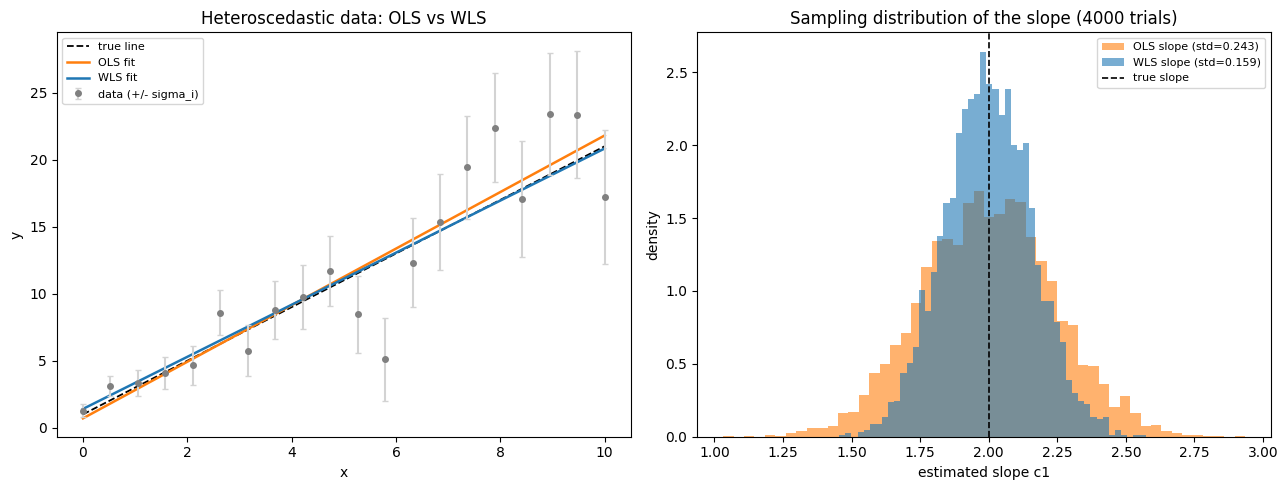

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# (좌) 한 실현의 적합선 + 오차막대
xx = np.linspace(x.min(), x.max(), 200)
ax[0].errorbar(x, y_demo, yerr=sigma, fmt="o", ms=4, color="gray",
               ecolor="lightgray", capsize=2, label="data (+/- sigma_i)", zorder=3)
ax[0].plot(xx, c0_true + c1_true*xx, "k--", lw=1.3, label="true line")
ax[0].plot(xx, c_ols[0] + c_ols[1]*xx, color="tab:orange", lw=1.8, label="OLS fit")
ax[0].plot(xx, c_wls[0] + c_wls[1]*xx, color="tab:blue", lw=1.8, label="WLS fit")
ax[0].set_xlabel("x"); ax[0].set_ylabel("y")
ax[0].set_title("Heteroscedastic data: OLS vs WLS")
ax[0].legend(fontsize=8)

# (우) 기울기 추정량 분포
ax[1].hist(est_ols[:, 1], bins=50, alpha=0.6, color="tab:orange",
           density=True, label=f"OLS slope (std={est_ols[:,1].std(ddof=1):.3f})")
ax[1].hist(est_wls[:, 1], bins=50, alpha=0.6, color="tab:blue",
           density=True, label=f"WLS slope (std={est_wls[:,1].std(ddof=1):.3f})")
ax[1].axvline(c1_true, color="k", ls="--", lw=1.2, label="true slope")
ax[1].set_xlabel("estimated slope c1"); ax[1].set_ylabel("density")
ax[1].set_title("Sampling distribution of the slope (4000 trials)")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **경험적 표준편차 ≈ 이론 표준편차**: 몬테카를로로 측정한 `std (empirical)` 가
   식 $(A^\top\Sigma^{-1}A)^{-1}$, $(A^\top A)^{-1}A^\top\Sigma A(A^\top A)^{-1}$ 의 대각근과 거의 일치한다.
   추정량 분산을 *닫힌 식*으로 예측할 수 있다는 확인이다.
2. **WLS 의 분산이 더 작다**: 두 추정량 모두 비편향(`mean ≈ 참값`)이지만,
   기울기 표준편차가 WLS 에서 작다(`variance reduction > 1`). 히스토그램에서 파란 분포가 더 *뾰족*하다.
   이것이 가우스–마르코프 정리의 가시화 — **같은 비편향이라면 $1/\sigma^2$ 가중이 최소분산**.
3. **왜인가**: OLS 는 $x$ 가 큰(따라서 잡음이 큰) 점들을 똑같이 신뢰해 기울기를 끌려다닌다.
   WLS 는 그런 점의 발언권을 $1/\sigma_i^2$ 로 줄여, 신뢰할 수 있는 점에 더 무게를 둔다.
4. 가중치를 *틀리게* 주면(예: 균등=OLS) 비편향성은 유지되지만 효율(분산)을 잃는다.
   가중치가 **참 분산의 역수**일 때 비로소 BLUE 가 된다.

> **결론**: 이분산 데이터에서 $w_i=1/\sigma_i^2$ 가중은 추정량을 더 정확하게(최소분산·BLUE) 만든다 — OLS 는 비편향이지만 비효율적이다.

**다음 문제로의 연결** — 1·2번은 "가중치"라는 자유도를 다뤘다. §9.3-3 은 *기저*라는 또 다른 자유도로 넘어간다: 주기적 데이터에 다항식 대신 **삼각함수 기저**를 쓰면, 등간격 표본에서의 직교성 덕분에 최소제곱이 **DFT 로 분해**된다.
